In [2]:
import numpy as np
from embedding_class import synthetic_data_generation, observation_map,embedding, MLE
import statsmodels.api as sm
from scipy.linalg import orthogonal_procrustes
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.linalg import solve_discrete_are

# 1. Phase 4: Kalman Filter Coupling and Nyström Lifting
### Kalman filter class

In [231]:
import numpy as np

class LinearKalmanFilter:
    def __init__(self, A, Q, H, R, Z0=None, P0=None):
        self.A = np.asarray(A)
        self.Q = np.asarray(Q)
        self.H = np.asarray(H)
        self.R = np.asarray(R)

        self.k = self.A.shape[0]

        if Z0 is None:
            Z0 = np.zeros(self.k)

        if P0 is None:
            P0 = np.eye(self.k)

        self.Ztm1_tm1 = np.asarray(Z0)
        self.Ptm1_tm1 = np.asarray(P0)

    def predict(self):
        self.Zt_tm1 = self.A @ self.Ztm1_tm1
        self.Pt_tm1 = self.A @ self.Ptm1_tm1 @ self.A.T + self.Q

        return self.Zt_tm1, self.Pt_tm1

    def update(self, z):
        z = np.asarray(z)

        S = self.H @ self.Pt_tm1 @ self.H.T + self.R
        K = self.Pt_tm1 @ self.H.T @ np.linalg.inv(S)
        self.Kt = K

        innovation = z - self.H @ self.Zt_tm1

        self.Zt_t = self.Zt_tm1 + K @ innovation
        self.Pt_t = (np.eye(self.k) - K @ self.H) @ self.Pt_tm1

        self.Ztm1_tm1 = self.Zt_t
        self.Ptm1_tm1 = self.Pt_t

        return self.Zt_t, self.Pt_t

    def one_step(self, z):
        self.predict()
        self.update(z)

        return self.Zt_t, self.Pt_t

    def run(self, Zobs):
        self.Zobs = np.asarray(Zobs)
        self.N = Zobs.shape[0]

        self.predicted = np.zeros((self.N, self.k))
        self.filtered = np.zeros((self.N, self.k))
        self.covariances = np.zeros((self.N, self.k, self.k))

        for i in range(self.N):
            
            Z_filt, P_filt = self.one_step(Zobs[i])
            self.predicted[i] = self.Zt_tm1
            self.filtered[i] = Z_filt
            self.covariances[i] = P_filt

        return self.filtered, self.predicted, self.covariances
    
    def ljung_box_test(self):
        inov = self.Zobs - self.predicted @ self.H.T
        df1 = sm.stats.acorr_ljungbox(inov[10:, 0], lags=6, return_df=True)
        df2 = sm.stats.acorr_ljungbox(inov[10:, 1], lags=6, return_df=True)

        df = pd.concat([df1, df2], axis=1)
        df.columns = ["lb_stat_1", "lb_pvalue_1", "lb_stat_2", "lb_pvalue_2"]

        return df      
    
    def riccati_convergence(self):

        if not hasattr(self, 'covariances'):
            raise AttributeError("Build covariances first by running run() first.")
        
        P_inf_prior = solve_discrete_are(
            self.A.T,
            self.H.T,
            self.Q,
            self.R
        )

        S_inf = self.H @ P_inf_prior @ self.H.T + self.R
        K_inf = P_inf_prior @ self.H.T @ np.linalg.inv(S_inf)
        P_inf_post = (np.eye(self.k) - K_inf @ self.H) @ P_inf_prior


        err = np.array([
            np.linalg.norm(self.covariances[t] - P_inf_post, ord="fro")
            for t in range(len(self.covariances))
        ])

        return err
        

In [216]:
def align_embedding(Y, Psi):
    """
    Align diffusion coordinates Psi to latent coordinates Y
    using orthogonal Procrustes alignment.

    Returns:
        Y_c: centred latent coordinates
        Psi_align: centred and aligned embedding
        R: orthogonal transformation
    """

    # centre both clouds
    Y_c = Y - Y.mean(axis=0)
    Psi_c = Psi - Psi.mean(axis=0)
    # best orthogonal map Psi_c @ R ≈ Y_c
    R, _ = orthogonal_procrustes(Psi_c, Y_c)
    # aligned embedding
    Psi_align = Psi_c @ R

    return Y_c, Psi_align, R

### Kalman filter class usage

In [233]:
LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2
SIGMA_ETAS, DS = [0.0, 0.05, 0.1, 0.2], [50, 100]

# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
clean = obs.clean_state()
Zobs = obs.sample_observation(0.05)

# Get embedding
dm = embedding()
w, Psi_noisy = dm.get_embedding(Zobs, alpha=1, k=2)

# Embedding for g(Xt) without noise
w_clean, Psi_clean = dm.get_embedding(clean["Gclean"], alpha=1, k=2)

# Aligning the coordinates
Psi_clean_c, Psi_noisy_align, R = align_embedding(Psi_clean, Psi_noisy)

In [234]:
Psi_for_mle = Psi_noisy_align - Psi_noisy_align.mean(axis=0)

mle = MLE()
kappa_hat, sigma_hat, _, _ = mle.ou_mle(Psi_for_mle, dt_eff)

k = 2
dt_eff = gap * dt

a = np.exp(-kappa_hat * dt_eff)

A = a * np.eye(k)

Q = (sigma_hat**2 / (2*kappa_hat)) * (1 - np.exp(-2*kappa_hat*dt_eff)) * np.eye(k)

H = np.eye(k)

R = np.cov((Psi_noisy_align - Psi_clean_c).T)

P0 = sigma_hat**2 / (2*kappa_hat) * np.eye(k)

Z0 = np.zeros(k)

kf = LinearKalmanFilter(A, Q, H, R, Z0=Z0, P0=P0)

filtered, predicted, covariates = kf.run(Psi_noisy_align)

In [ ]:
Y_c, filtered_aligned, R = align_embedding(latent.Y_geom, filtered)
Y_c, predicted_aligned, R = align_embedding(latent.Y_geom, predicted)
Y_c, Psi_aligned, R = align_embedding(latent.Y_geom, Psi_noisy)

scale = np.sum(Y_c * Psi_aligned) / np.sum(Psi_aligned**2)
Psi_aligned = Psi_aligned * scale
filtered_aligned = filtered_aligned * scale

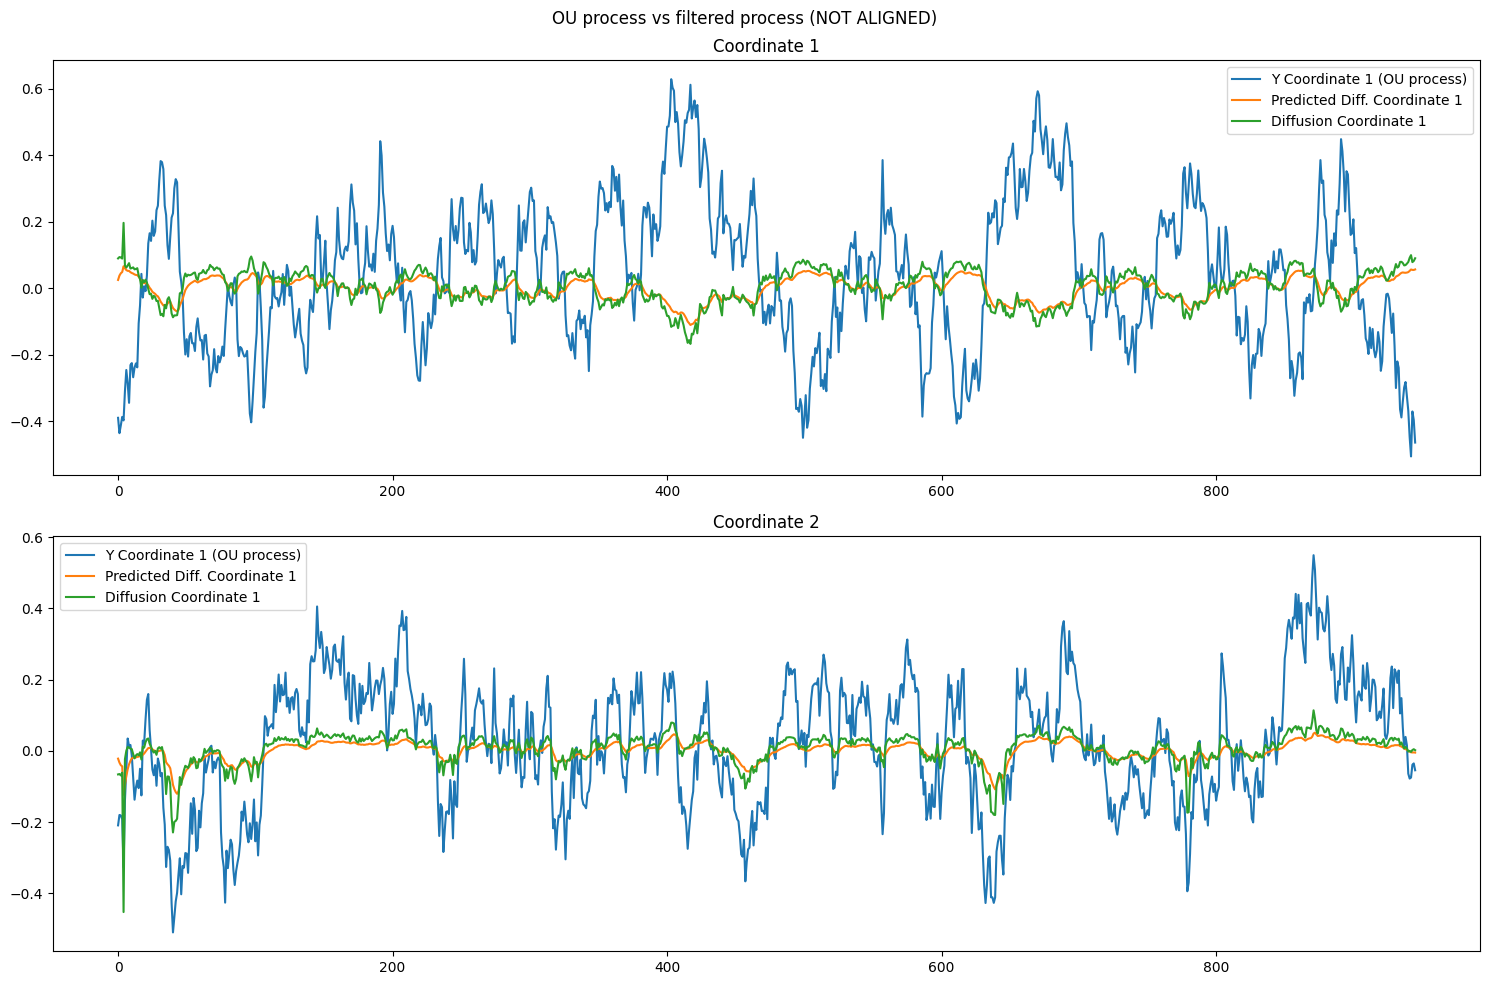

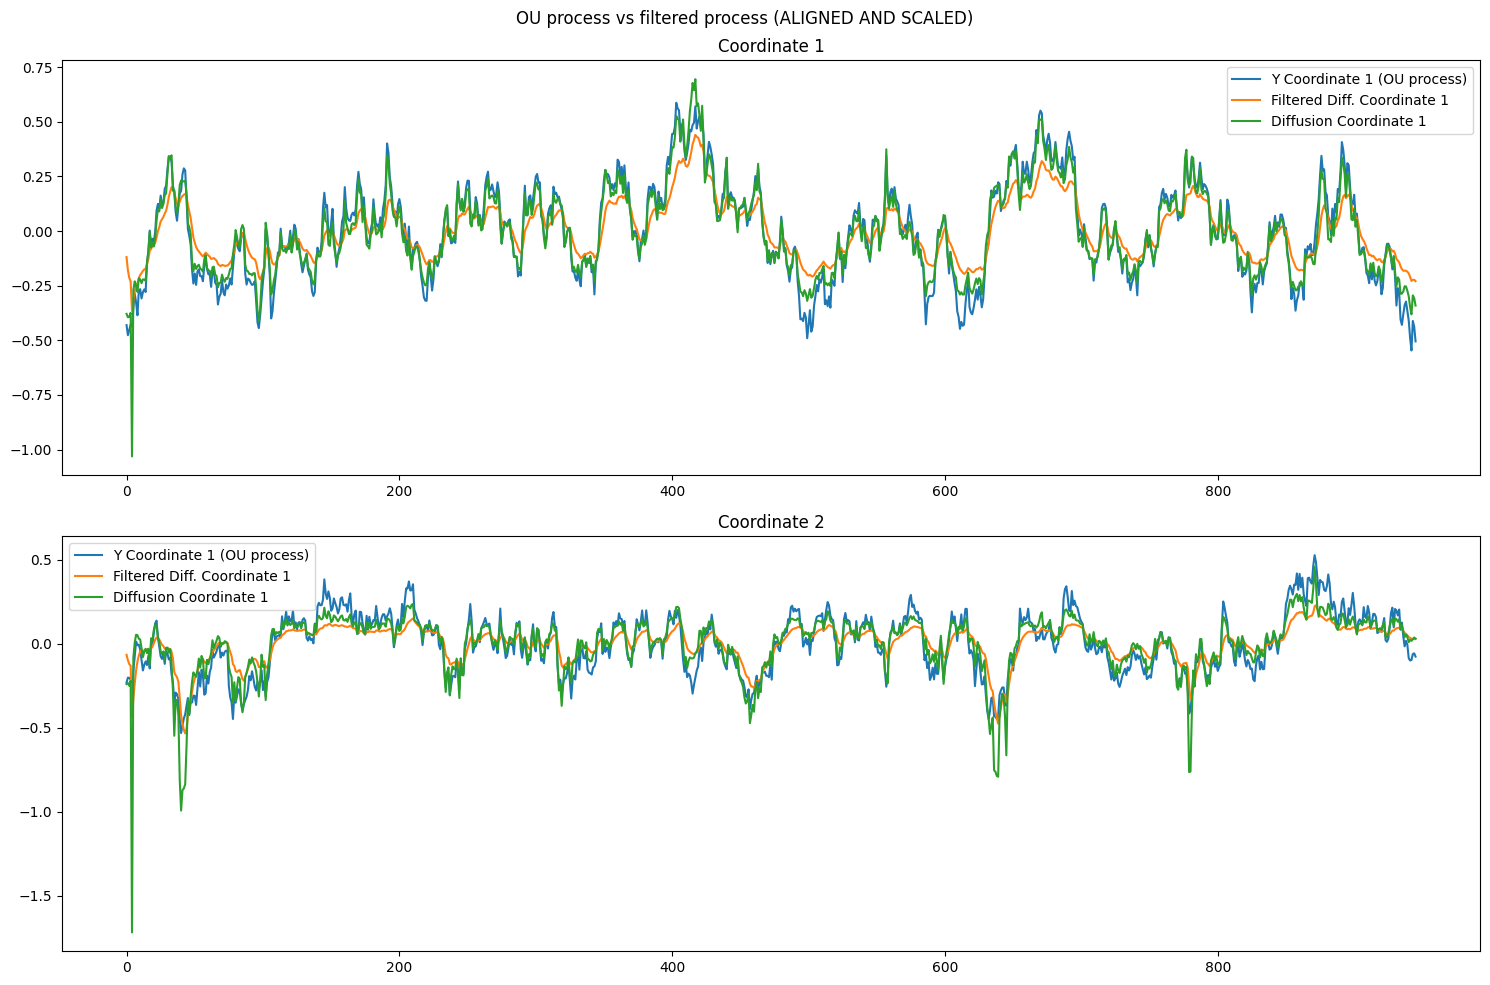

In [236]:
fig, ax = plt.subplots(2,1)
fig.set_figheight(10)
fig.set_figwidth(15)
fig.suptitle("OU process vs filtered process (NOT ALIGNED)")

ax[0].set_title("Coordinate 1")
ax[0].plot(latent.Y_geom[:,0], label="Y Coordinate 1 (OU process)")
# ax[0].plot(filtered[:,0], label="Filtered Diff. Coordinate 1")
ax[0].plot(filtered[:,0], label="Predicted Diff. Coordinate 1")
ax[0].plot(Psi_noisy[:,0], label="Diffusion Coordinate 1")
ax[0].legend()

ax[1].set_title("Coordinate 2")
ax[1].plot(latent.Y_geom[:,1], label="Y Coordinate 1 (OU process)")
# ax[1].plot(filtered[:,1], label="Filtered Diff. Coordinate 1")
ax[1].plot(filtered[:,1], label="Predicted Diff. Coordinate 1")
ax[1].plot(Psi_noisy[:,1], label="Diffusion Coordinate 1")
ax[1].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(2,1)
fig.set_figheight(10)
fig.set_figwidth(15)
fig.suptitle("OU process vs filtered process (ALIGNED AND SCALED)")

ax[0].set_title("Coordinate 1")
ax[0].plot(Y_c[:,0], label="Y Coordinate 1 (OU process)")
ax[0].plot(filtered_aligned[:,0], label="Filtered Diff. Coordinate 1")
#ax[0].plot(predicted_aligned[:,0], label="Predicted Diff. Coordinate 1")
ax[0].plot(Psi_aligned[:,0], label="Diffusion Coordinate 1")
ax[0].legend()


ax[1].set_title("Coordinate 2")
ax[1].plot(Y_c[:,1], label="Y Coordinate 1 (OU process)")
ax[1].plot(filtered_aligned[:,1], label="Filtered Diff. Coordinate 1")
#ax[1].plot(predicted_aligned[:,1], label="Predicted Diff. Coordinate 1")
ax[1].plot(Psi_aligned[:,1], label="Diffusion Coordinate 1")
ax[1].legend()

fig.tight_layout()
plt.legend()
plt.show()


In [239]:
kf.ljung_box_test()

,lb_stat_1,lb_pvalue_1,lb_stat_2,lb_pvalue_2
1,612.428575,3.315361e-135,558.765878,1.559849e-123
2,990.951281,6.571482e-216,855.749264,1.501096e-186
3,1228.964925,3.808203e-266,1038.432307,8.276303e-225
4,1386.901499,4.784180e-299,1158.154293,1.877053e-249
5,1493.504322,0.000000e+00,1246.582873,2.384590e-267
6,1572.149274,0.000000e+00,1316.510813,2.886608e-281


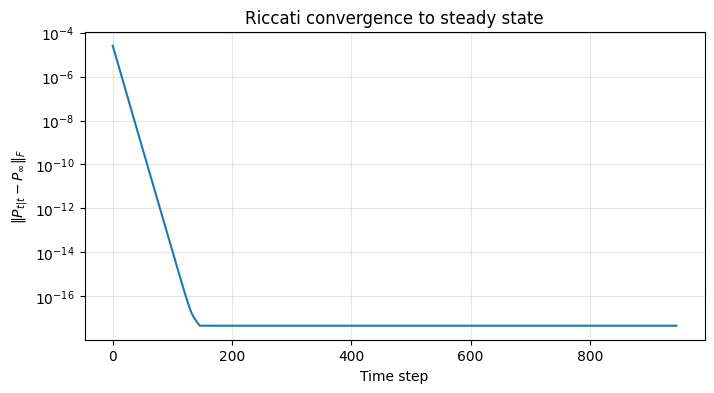

In [240]:
kf = LinearKalmanFilter(A, Q, H, R, Z0, P0)
filtered, predicted, covariates = kf.run(Psi_noisy[:, :2])
err = kf.riccati_convergence()


plt.figure(figsize=(8, 4))
plt.semilogy(err)
plt.xlabel("Time step")
plt.ylabel(r"$\|P_{t|t} - P_\infty\|_F$")
plt.title("Riccati convergence to steady state")
plt.grid(True, alpha=0.3)
plt.show()

# 1.2. Task 4.2: Nyström extension for out-of-sample lifting

Store the training point cloud, the kernel bandwidth ε
⋆
, the empirical degrees {qi}, and
the eigenpairs {(λℓ
, ϕℓ)} from the Phase 2 diffusion map

In [ ]:
# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

X = latent.X
X_geom = latent.X_geom

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
clean = obs.clean_state()
Zobs = obs.sample_observation(0.05)

N = Zobs.shape[0]
n_train = int(0.7 * N)

Z_train = Zobs[:n_train]
Z_hold = Zobs[n_train:]

# Get embedding
dm_train = embedding()
w_train, Psi_train = dm_train.get_embedding(Z_train, alpha=1, k=2)

store_train = {
    "Psi": Psi_train,
    "Zobs": Z_train,
    "eps": dm_train.eps,
    "alpha": dm_train.alpha,
    "q": dm_train.q,
    "w": dm_train.w,
    "v": dm_train.v,
}

In [137]:
def oos_lifting(y_new, store):
    eps = store["eps"]
    alpha = store["alpha"]

    Psi = store["Psi"]
    k = Psi.shape[1]

    lambdas = store["w"][1:k+1]
    phi = store["v"][:, 1:k+1]

    # raw kernel to training points
    w_new = np.exp(-np.sum((store["Zobs"] - y_new)**2, axis=1) / eps)

    # alpha normalisation
    q_new = np.sum(w_new)
    w_alpha = w_new / ((q_new**alpha) * (store["q"]**alpha))

    # row-normalise to transition probabilities
    p_new = w_alpha / np.sum(w_alpha)

    # Nystrom extension of right eigenvectors
    phi_new = (p_new @ phi) / lambdas

    # diffusion coordinates at t=1
    psi_new = lambdas * phi_new

    return psi_new

### Testing of out-of-sample lifting
Idempotence

In [256]:
Z_train[0].shape

(100,)

In [257]:
idemp_errors = np.zeros(n_train)

for i in range(n_train):
    reembedded = oos_lifting(Z_train[i], store_train)
    idemp_errors[i] = np.linalg.norm(reembedded - Psi_train[i])

print("mean idempotence error:", idemp_errors.mean())
print("max idempotence error:", idemp_errors.max())

mean idempotence error: 0.06948071665275607
max idempotence error: 0.5518626704223047


Continuity

In [261]:
eg = Z_train[0]
D = eg.shape[0]

psi_base = oos_lifting(eg, store_train)

deltas = np.logspace(-5, -1, 30)
errors = np.zeros_like(deltas)

direction = np.ones(D)
direction /= np.linalg.norm(direction)

for i, delta in enumerate(deltas):
    z_new = eg + delta * direction
    psi_new = oos_lifting(z_new, store_train)

    errors[i] = np.linalg.norm(psi_new - psi_base)

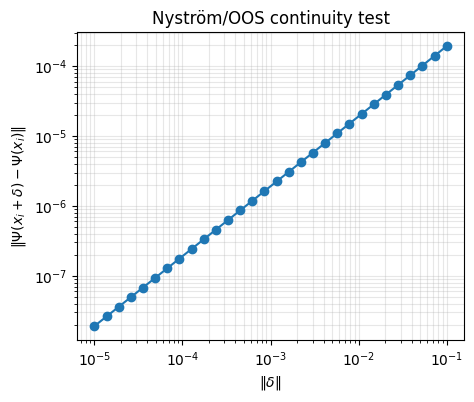

continuity slope: 1.000719043035186


In [262]:
plt.figure(figsize=(5,4))
plt.loglog(deltas, errors, marker="o")
plt.xlabel(r"$\|\delta\|$")
plt.ylabel(r"$\|\Psi(x_i+\delta)-\Psi(x_i)\|$")
plt.title("Nyström/OOS continuity test")
plt.grid(True, which="both", alpha=0.3)
plt.show()

slope, intercept = np.polyfit(np.log(deltas), np.log(errors), 1)
print("continuity slope:", slope)

Out-of-sample on the canonical manifolds

In [250]:
Psi_hold_oos = np.zeros((len(Z_hold), 2))

for i, y in enumerate(Z_hold):
    Psi_hold_oos[i] = oos_lifting(y, store_train)

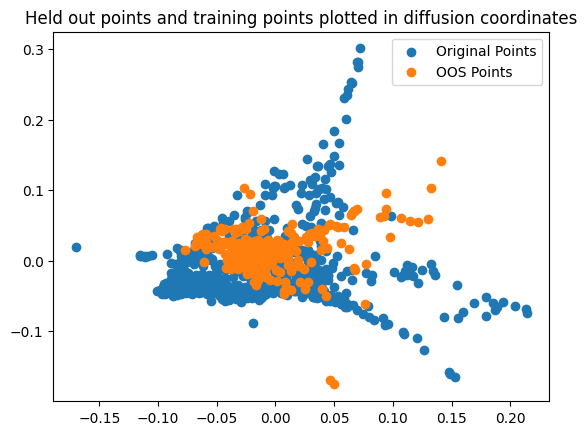

In [251]:
plt.scatter(store_train["Psi"][:, 0], store_train["Psi"][:, 1], label="Original Points")
plt.scatter(Psi_hold_oos[:, 0], Psi_hold_oos[:, 1], label="OOS Points")
plt.title("Held out points and training points plotted in diffusion coordinates")
plt.legend()
plt.show()

Looks good

# 1.3. Task 4.3: Closing the JDKF loop on synthetic data

In [266]:
LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2
# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

X_geom = latent.X_geom; Y_geom = latent.Y_geom

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
Gclean = obs.sample_observation(0.00)
Zobs = obs.sample_observation(0.05)

N = Zobs.shape[0]
n_train = int(N * 0.7)

### SPLIT INTO TRAIN AND VAL
Zobs_train = Zobs[:n_train, :]; Zobs_val = Zobs[n_train:, :]
Gclean_train = Gclean[:n_train, :]; Gclean_val = Gclean[n_train:, :]
X_train = X_geom[:n_train, :]; Y_test = Y_geom[n_train:, :]

# Get embedding
dm = embedding()
w, Psi_noisy = dm.get_embedding(Zobs_train, alpha=1, k=2)
_, Psi_clean = dm.get_embedding(Gclean_train, alpha=1, k=2)
q = dm.q
eps = dm.eps; 
w, v = dm.w, dm.v
alpha = dm.alpha

store_train = {"Psi": Psi_noisy, "Zobs": Zobs_train, "X": X_train, "eps": eps, "alpha": alpha, "q": q, "w": w, "v": v}

# Estimate OU parameters
mle = MLE()
kappa_hat, sigma_hat, _, _ = mle.ou_mle(Psi_noisy, dt_eff)

k = 2
dt_eff = gap * dt
a = np.exp(-kappa_hat * dt_eff)
A = a * np.eye(k)
Q = (sigma_hat**2 / (2*kappa_hat)) * (1 - np.exp(-2*kappa_hat*dt_eff)) * np.eye(k)
H = np.eye(k)
R = np.cov((Psi_noisy - Psi_clean).T)
P0 = sigma_hat**2 / (2*kappa_hat) * np.eye(k)
Z0 = np.zeros(k)

kf = LinearKalmanFilter(A, Q, H, R, Z0=Z0, P0=P0)

### RUN KALMAN FILTER UP TO TRAIN DATA
filtered, predicted, covariates = kf.run(Psi_noisy)


For each streaming obeservation, lift to the diffusion coordinates and run the filter and predict steps of the Kalman filter

In [271]:
ys = Zobs_val

new_filtered = np.zeros((N-n_train, 2))
new_predicted = np.zeros((N-n_train, 2))
new_lifted = np.zeros((N-n_train, 2))

for i, y in enumerate(ys):
    zt = oos_lifting(y, store_train)

    z_pred, P_pred = kf.predict()
    z_filt, P_filt = kf.update(zt)

    new_lifted[i] = zt
    new_filtered[i] = z_filt
    new_predicted[i] = z_pred


Didn't look good without scaling, so I scaled it. How would we get this scaling in real life? Would it even matter in real-world situation? Just for now to see how closely it matches?

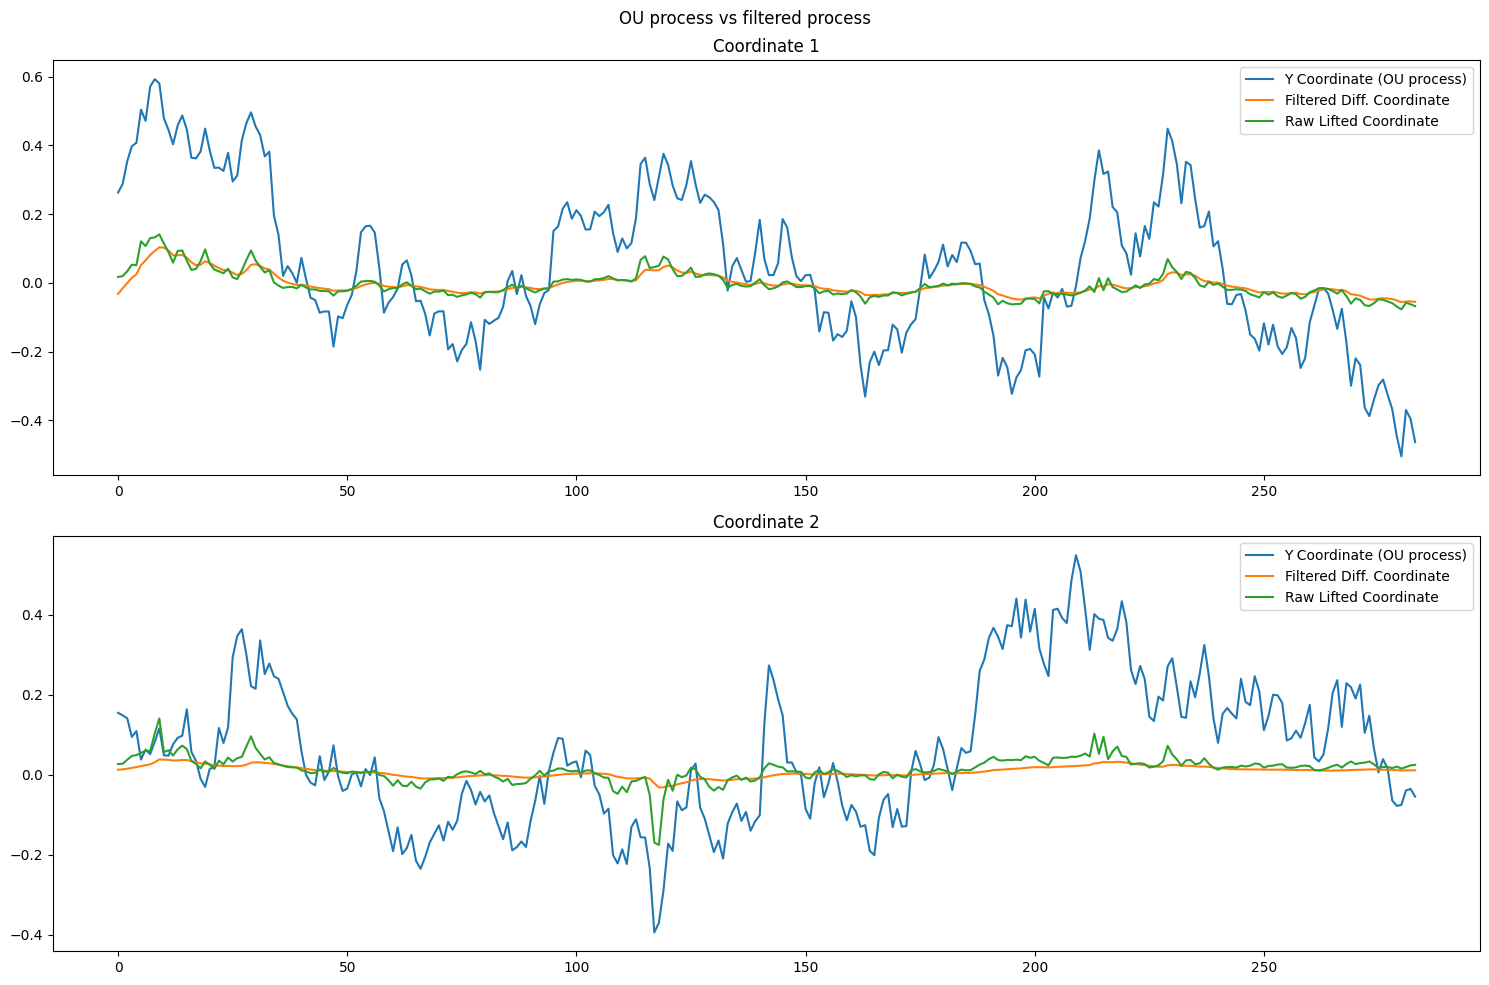

In [272]:

fig, ax = plt.subplots(2,1)
fig.set_figheight(10)
fig.set_figwidth(15)
fig.suptitle("OU process vs filtered process")

ax[0].set_title("Coordinate 1")
ax[0].plot(Y_test[:, 0], label="Y Coordinate (OU process)")
ax[0].plot(new_filtered[:,0], label="Filtered Diff. Coordinate")
# ax[0].plot(new_predicted[:,0], label="Predicted Diff. Coordinate")
ax[0].plot(new_lifted[:,0], label="Raw Lifted Coordinate")
ax[0].legend()

ax[1].set_title("Coordinate 2")
ax[1].plot(Y_test[:, 1], label="Y Coordinate (OU process)")
ax[1].plot(new_filtered[:,1], label="Filtered Diff. Coordinate")
# ax[1].plot(new_predicted[:,1], label="Predicted Diff. Coordinate")
ax[1].plot(new_lifted[:,1], label="Raw Lifted Coordinate")
ax[1].legend()

fig.tight_layout()
plt.show()


Aligning and scaling things to compare to Y

Mean squared error of filtered coordinates: 0.030287058073492152
Mean squared error of raw lifted coordinates: 0.01853309176638902


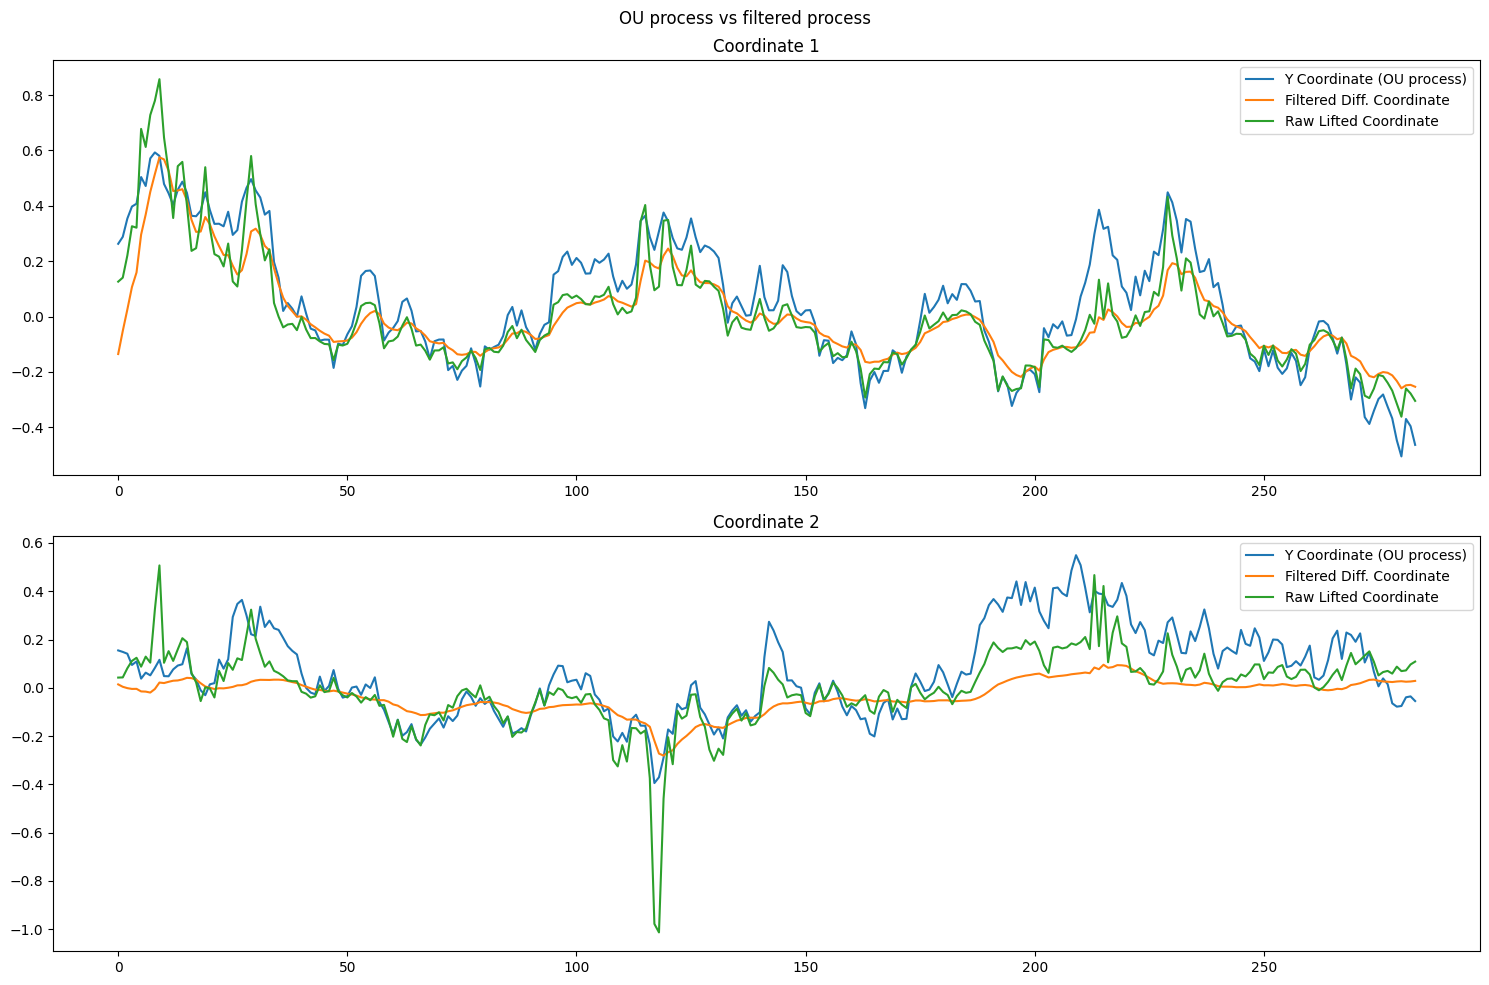

In [277]:
Y_c, lifted_align, R_align = align_embedding(Y_test, new_lifted)

filtered_c = new_filtered - new_lifted.mean(axis=0)
filtered_align = filtered_c @ R_align

scale = np.sum(Y_c * lifted_align) / np.sum(lifted_align**2)

lifted_align = scale * lifted_align
filtered_align = scale * filtered_align

mse_filtered = np.mean(np.sum((Y_c - filtered_align)**2, axis=1))
mse_lifted = np.mean(np.sum((Y_c - lifted_align)**2, axis=1))

print(f"Mean squared error of filtered coordinates: {mse_filtered}")
print(f"Mean squared error of raw lifted coordinates: {mse_lifted}")


fig, ax = plt.subplots(2,1)
fig.set_figheight(10)
fig.set_figwidth(15)
fig.suptitle("OU process vs filtered process")

ax[0].set_title("Coordinate 1")
ax[0].plot(Y_test[:, 0], label="Y Coordinate (OU process)")
ax[0].plot(filtered_align[:,0], label="Filtered Diff. Coordinate")
# ax[0].plot(new_predicted[:,0], label="Predicted Diff. Coordinate")
ax[0].plot(lifted_align[:,0], label="Raw Lifted Coordinate")
ax[0].legend()

ax[1].set_title("Coordinate 2")
ax[1].plot(Y_test[:, 1], label="Y Coordinate (OU process)")
ax[1].plot(filtered_align[:,1], label="Filtered Diff. Coordinate")
# ax[1].plot(new_predicted[:,1], label="Predicted Diff. Coordinate")
ax[1].plot(lifted_align[:,1], label="Raw Lifted Coordinate")
ax[1].legend()

fig.tight_layout()
plt.show()

This does not look like it has worked